In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [30]:
!pip install xlrd openpyxl


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

df = pd.read_excel(url, header=1)

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset loaded!
Shape: (30000, 25)

First 5 rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  def

In [32]:

print("EXPLORATORY DATA ANALYSIS")

print("\n1. Dataset Info:")
print(df.info())

target_col = 'default payment next month'
print(f"\n2. Target Variable: '{target_col}'")
print(df[target_col].value_counts())
print("\nPercentages:")
print(df[target_col].value_counts(normalize=True) * 100)

EXPLORATORY DATA ANALYSIS

1. Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   

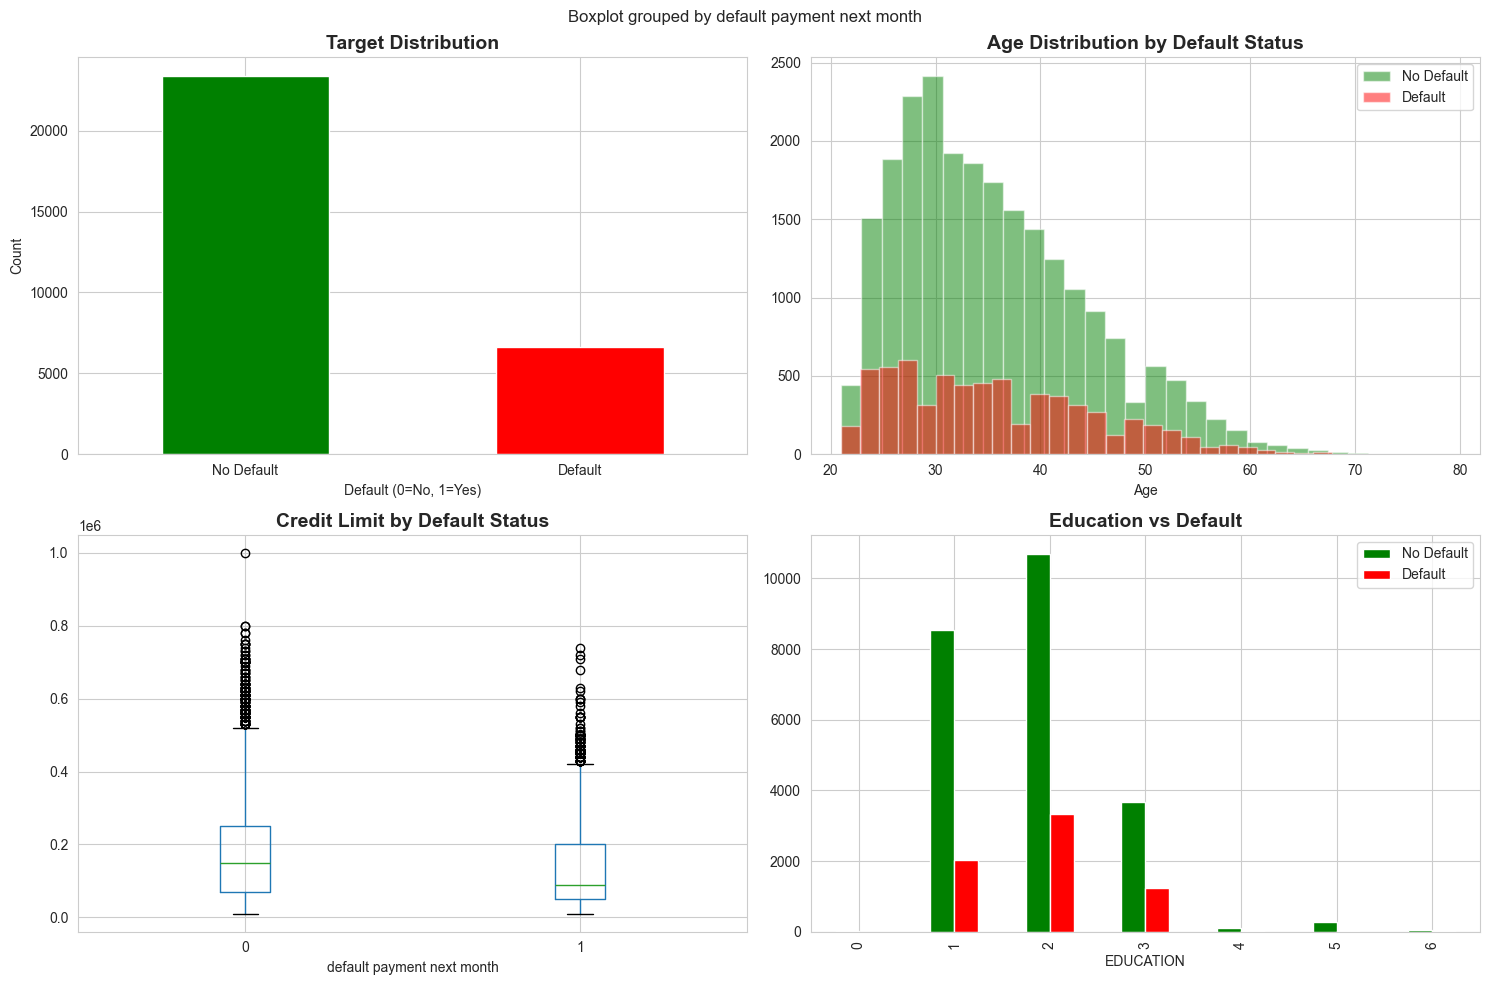

Visualizations created!


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Target distribution
df[target_col].value_counts().plot(kind='bar', ax=axes[0,0], color=['green', 'red'])
axes[0,0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Default (0=No, 1=Yes)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(['No Default', 'Default'], rotation=0)

# 2. Age distribution
axes[0,1].hist(df[df[target_col]==0]['AGE'], bins=30, alpha=0.5, label='No Default', color='green')
axes[0,1].hist(df[df[target_col]==1]['AGE'], bins=30, alpha=0.5, label='Default', color='red')
axes[0,1].set_title('Age Distribution by Default Status', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# 3. Credit Limit
df.boxplot(column='LIMIT_BAL', by=target_col, ax=axes[1,0])
axes[1,0].set_title('Credit Limit by Default Status', fontsize=14, fontweight='bold')

# 4. Education
education_default = df.groupby(['EDUCATION', target_col]).size().unstack()
education_default.plot(kind='bar', ax=axes[1,1], color=['green', 'red'])
axes[1,1].set_title('Education vs Default', fontsize=14, fontweight='bold')
axes[1,1].legend(['No Default', 'Default'])

plt.tight_layout()
plt.show()

print("Visualizations created!")

In [34]:

print("DATA PREPROCESSING")

# Make a copy
df_clean = df.copy()

# 1. Drop ID column
df_clean = df_clean.drop('ID', axis=1)
print("\n1. Dropped ID column")

# 2. Rename target
target_col = 'default payment next month'
df_clean = df_clean.rename(columns={target_col: 'default'})
print("2. Renamed target column to 'default'")

# 3. CHECK FOR MISSING VALUES
print("\n3. Checking for missing values...")
missing_counts = df_clean.isnull().sum()
print(f"Total missing values: {missing_counts.sum()}")

if missing_counts.sum() > 0:
    print("\nColumns with missing values:")
    print(missing_counts[missing_counts > 0])
    
    # Fill missing values
    # For numerical columns: fill with median
    # For categorical columns: fill with mode
    
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            if df_clean[col].dtype in ['int64', 'float64']:
                # Fill numerical with median
                df_clean[col].fillna(df_clean[col].median(), inplace=True)
                print(f"   Filled {col} with median")
            else:
                # Fill categorical with mode
                df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
                print(f"   Filled {col} with mode")
    
    print(f"\n All missing values handled!")
else:
    print(" No missing values found!")

# 4. Clean categorical variables
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace([0, 5, 6], 4)
df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace(0, 3)
print("\n4. Cleaned categorical variables")

# 5. Create new features
df_clean['avg_bill'] = df_clean[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
                                   'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean(axis=1)

df_clean['avg_payment'] = df_clean[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 
                                      'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean(axis=1)

df_clean['utilization'] = df_clean['avg_bill'] / (df_clean['LIMIT_BAL'] + 1)
df_clean['payment_ratio'] = df_clean['avg_payment'] / (df_clean['avg_bill'] + 1)

print("5. Created new features")

# 6. FINAL CHECK - ensure no NaN or inf values
print("\n6. Final validation...")

# Replace inf with large number
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

# Check again for NaN
if df_clean.isnull().sum().sum() > 0:
    print("Still have NaN values after feature engineering")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
    
    # Fill any remaining NaN
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"   Filled {col}")

print(f"\n Final check passed!")
print(f"Final shape: {df_clean.shape}")
print(f"Total NaN values: {df_clean.isnull().sum().sum()}")
print(f"Total inf values: {np.isinf(df_clean.select_dtypes(include=[np.number])).sum().sum()}")

DATA PREPROCESSING

1. Dropped ID column
2. Renamed target column to 'default'

3. Checking for missing values...
Total missing values: 0
 No missing values found!

4. Cleaned categorical variables
5. Created new features

6. Final validation...
Still have NaN values after feature engineering
payment_ratio    2
dtype: int64
   Filled payment_ratio

 Final check passed!
Final shape: (30000, 28)
Total NaN values: 2
Total inf values: 0


In [35]:

print("PREPARING DATA FOR MODELING")


# Separate features and target
X = df_clean.drop('default', axis=1)
y = df_clean['default']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

# VERIFY NO NAN/INF BEFORE SPLITTING
print("\n Pre-split verification:")
print(f"X has NaN: {X.isnull().sum().sum()}")
print(f"X has inf: {np.isinf(X.select_dtypes(include=[np.number])).sum().sum()}")
print(f"y has NaN: {y.isnull().sum()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# VERIFY AGAIN AFTER SPLIT
print("\n Post-split verification:")
print(f"X_train has NaN: {X_train.isnull().sum().sum()}")
print(f"X_test has NaN: {X_test.isnull().sum().sum()}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# VERIFY SCALED DATA
print("\n Post-scaling verification:")
print(f"X_train_scaled has NaN: {np.isnan(X_train_scaled).sum()}")
print(f"X_test_scaled has NaN: {np.isnan(X_test_scaled).sum()}")

if np.isnan(X_train_scaled).sum() > 0 or np.isnan(X_test_scaled).sum() > 0:
    print("\n WARNING: Scaled data contains NaN!")
    print("This might be due to zero standard deviation in some features")
    
    # Fix: replace NaN in scaled data with 0
    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)
    print(" Replaced NaN with 0 in scaled data")

print("\n Data ready for modeling!")

PREPARING DATA FOR MODELING
Features (X): (30000, 27)
Target (y): (30000,)

 Pre-split verification:
X has NaN: 2
X has inf: 0
y has NaN: 0

Train set: (24000, 27)
Test set: (6000, 27)

 Post-split verification:
X_train has NaN: 2
X_test has NaN: 0

 Post-scaling verification:
X_train_scaled has NaN: 2
X_test_scaled has NaN: 0

This might be due to zero standard deviation in some features
 Replaced NaN with 0 in scaled data

 Data ready for modeling!


In [36]:
def evaluate_model(name, y_true, y_pred, y_pred_proba):
    """Evaluate a classification model"""
    print(f"{name.upper()} - RESULTS")

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\nAccuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    
    return {
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

print("Helper function defined!")

Helper function defined!


In [37]:
print(" BUILDING LOGISTIC REGRESSION")

lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

results_lr = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_pred_proba_lr)

 BUILDING LOGISTIC REGRESSION
LOGISTIC REGRESSION - RESULTS

Accuracy:  0.6852
Precision: 0.3722
Recall:    0.6164
F1-Score:  0.4641
ROC-AUC:   0.7096

Confusion Matrix:
[[3293 1380]
 [ 509  818]]


In [38]:
print(" BUILDING DECISION TREE")

dt_model = DecisionTreeClassifier(
    random_state=42, max_depth=10, min_samples_split=100, class_weight='balanced'
)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

results_dt = evaluate_model('Decision Tree', y_test, y_pred_dt, y_pred_proba_dt)

 BUILDING DECISION TREE
DECISION TREE - RESULTS

Accuracy:  0.7323
Precision: 0.4275
Recall:    0.6194
F1-Score:  0.5058
ROC-AUC:   0.7497

Confusion Matrix:
[[3572 1101]
 [ 505  822]]


In [39]:
print(" BUILDING RANDOM FOREST")

rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, max_depth=15, 
    min_samples_split=50, class_weight='balanced', n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

results_rf = evaluate_model('Random Forest', y_test, y_pred_rf, y_pred_proba_rf)

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 10 Important Features:")
print(feature_importance.head(10))

 BUILDING RANDOM FOREST
RANDOM FOREST - RESULTS

Accuracy:  0.7897
Precision: 0.5224
Recall:    0.5705
F1-Score:  0.5454
ROC-AUC:   0.7750

Confusion Matrix:
[[3981  692]
 [ 570  757]]

🔝 Top 10 Important Features:
          feature  importance
5           PAY_0    0.201004
6           PAY_2    0.094796
25    utilization    0.049058
24    avg_payment    0.047138
7           PAY_3    0.045665
0       LIMIT_BAL    0.040730
8           PAY_4    0.040141
26  payment_ratio    0.035819
11      BILL_AMT1    0.035217
17       PAY_AMT1    0.033247


In [40]:
print(" BUILDING XGBOOST")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

results_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb, y_pred_proba_xgb)

 BUILDING XGBOOST
XGBOOST - RESULTS

Accuracy:  0.7657
Precision: 0.4764
Recall:    0.6006
F1-Score:  0.5313
ROC-AUC:   0.7743

Confusion Matrix:
[[3797  876]
 [ 530  797]]


In [41]:
print(" BUILDING CATBOOST")

cat_model = CatBoostClassifier(
    iterations=100, depth=6, learning_rate=0.1,
    class_weights=[1, scale_pos_weight], random_state=42, verbose=False
)
cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)
y_pred_proba_cat = cat_model.predict_proba(X_test)[:, 1]

results_cat = evaluate_model('CatBoost', y_test, y_pred_cat, y_pred_proba_cat)

 BUILDING CATBOOST
CATBOOST - RESULTS

Accuracy:  0.7635
Precision: 0.4734
Recall:    0.6179
F1-Score:  0.5361
ROC-AUC:   0.7807

Confusion Matrix:
[[3761  912]
 [ 507  820]]


In [42]:
# Combine results
all_results = pd.DataFrame([
    results_lr, results_dt, results_rf, results_xgb, results_cat
])

print("\n MODEL COMPARISON")
print("="*80)
print(all_results.to_string(index=False))

best_model_idx = all_results['ROC-AUC'].idxmax()
best_model_name = all_results.loc[best_model_idx, 'Model']
best_model_auc = all_results.loc[best_model_idx, 'ROC-AUC']

print(f"\n BEST MODEL: {best_model_name} (ROC-AUC: {best_model_auc:.4f})")


 MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.685167   0.372157 0.616428  0.464113 0.709585
      Decision Tree  0.732333   0.427457 0.619442  0.505846 0.749731
      Random Forest  0.789667   0.522429 0.570460  0.545389 0.775045
            XGBoost  0.765667   0.476390 0.600603  0.531333 0.774273
           CatBoost  0.763500   0.473441 0.617935  0.536123 0.780718

 BEST MODEL: CatBoost (ROC-AUC: 0.7807)


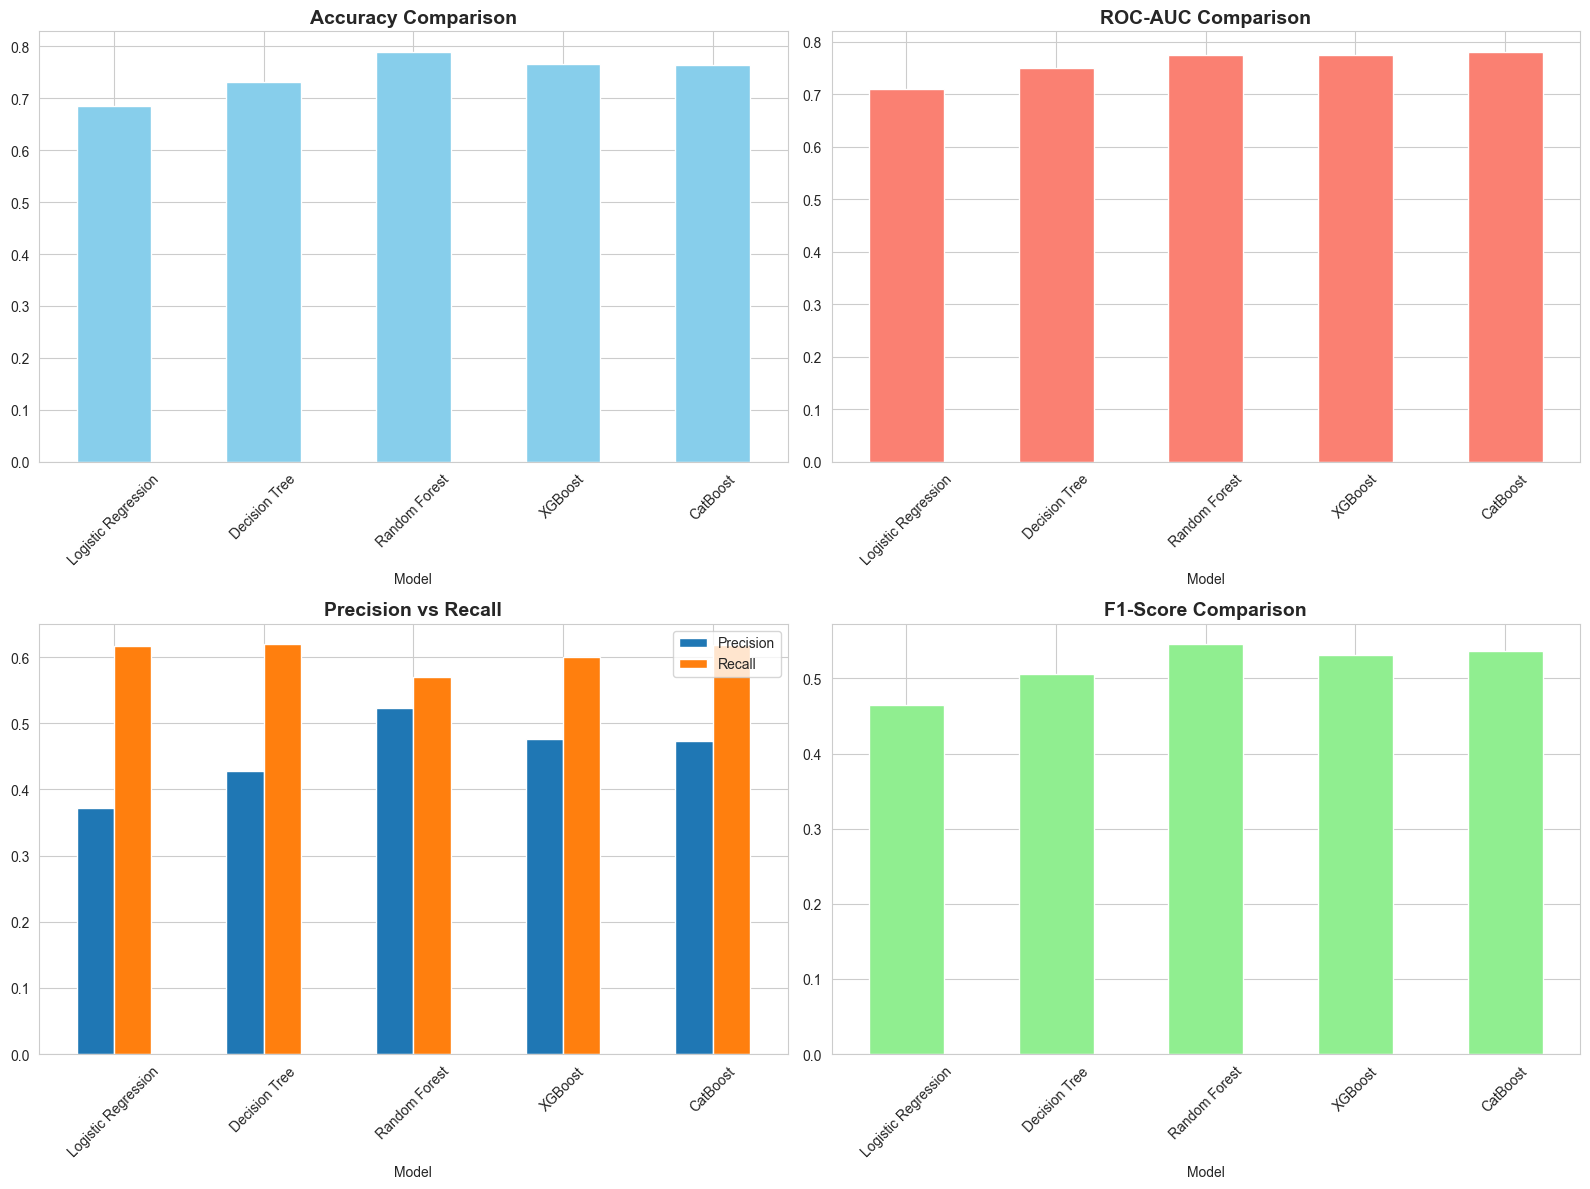

Comparison complete!


In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy
all_results.plot(x='Model', y='Accuracy', kind='bar', ax=axes[0,0], 
                 legend=False, color='skyblue')
axes[0,0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)

# ROC-AUC
all_results.plot(x='Model', y='ROC-AUC', kind='bar', ax=axes[0,1], 
                 legend=False, color='salmon')
axes[0,1].set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

# Precision vs Recall
all_results.plot(x='Model', y=['Precision', 'Recall'], kind='bar', ax=axes[1,0])
axes[1,0].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)

# F1-Score
all_results.plot(x='Model', y='F1-Score', kind='bar', ax=axes[1,1], 
                 legend=False, color='lightgreen')
axes[1,1].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Comparison complete!")

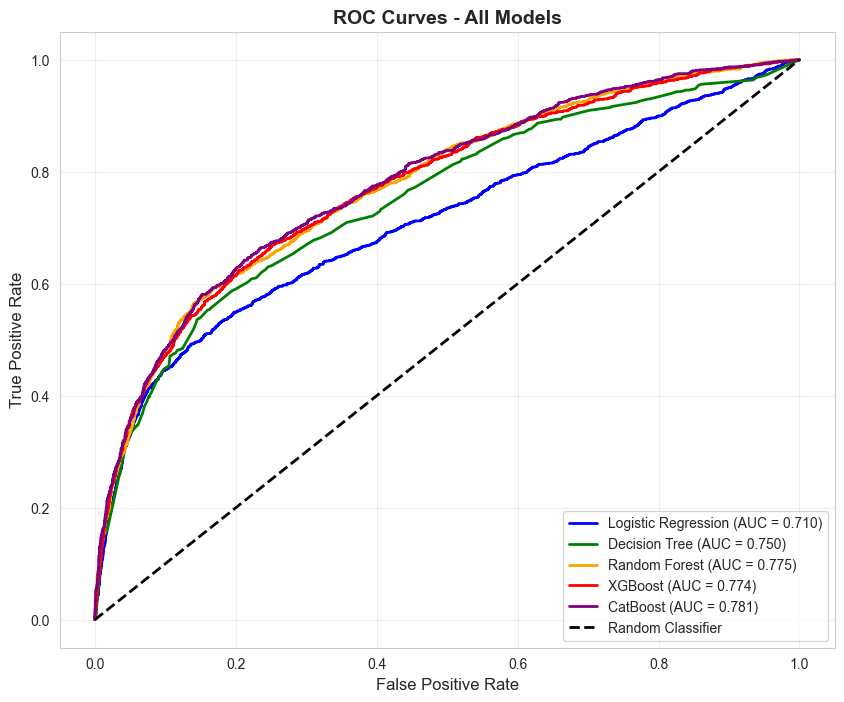

 Done!


In [44]:
plt.figure(figsize=(10, 8))

models_data = [
    (y_pred_proba_lr, 'Logistic Regression', 'blue'),
    (y_pred_proba_dt, 'Decision Tree', 'green'),
    (y_pred_proba_rf, 'Random Forest', 'orange'),
    (y_pred_proba_xgb, 'XGBoost', 'red'),
    (y_pred_proba_cat, 'CatBoost', 'purple')
]

for pred_proba, name, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, pred_proba)
    auc = roc_auc_score(y_test, pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

print(" Done!")